In [2]:
#import libraries
import numpy as np
import pandas as pd
import pickle
import json
import tensorflow as tf

from pathlib import Path

print("libraries imported")

libraries imported


In [3]:
#load configuration and tokenizer
processed_dir = Path("../data/processed")

#Load configuration
with open(processed_dir / "config.json", "r") as file:
    config = json.load(file)

VOCAB_SIZE = config["vocab_size"]
CONTEXT_LENGTH = config["context_length"]

print("VOCAB_SIZE:", VOCAB_SIZE)
print("CONTEXT_LENGTH:", CONTEXT_LENGTH)

#Load the same tokenizer used during training 
with open(processed_dir / "tokennizer.pkl","rb") as file:
    tokenizer = pickle.load(file)
print("Tokenizer loaded successfully")

VOCAB_SIZE: 20000
CONTEXT_LENGTH: 20
Tokenizer loaded successfully


In [4]:
 
#Load clean test documents
test_clean_path = processed_dir / "test_clean.txt"

#Each line in test_clean.txt represents one cleaned medical document
with open(test_clean_path,"r", encoding="utf-8") as file:
    test_docs = [
        line.strip()
        for line in file
        if line.strip()
    ]

print("Number of test documents:",len(test_docs))
print("\nExample test documents:")
print(test_docs[0][:500])

Number of test documents: 14442

Example test documents:
of limbal dermoids. we reviewed the clinical files of 10 patients who had undergone excision of unilateral epibulbar limbal dermoids. preoperatively, all of the affected eyes had worse visual acuity (p less than .02) and more astigmatism (p less than .01) than the contralateral eyes. postoperatively, every patient was cosmetically improved. of the eight patients for whom both preoperative and postoperative visual acuity measurements had been obtained, in six it had changed minimally (less than o


In [5]:
#tokenize test data
test_sequences = tokenizer.texts_to_sequences(test_docs)
print("Documents converted:",len(test_sequences))
print("\nFirst tokenized document:")
print(test_sequences[0][:30])

Documents converted: 14442

First tokenized document:
[3, 15370, 17291, 39, 474, 2, 58, 12154, 3, 64, 9, 54, 26, 1419, 1180, 3, 1328, 1, 15370, 17291, 2021, 46, 3, 2, 760, 1122, 26, 2325, 693, 3203]


In [6]:
import numpy as np

num_test_samples = sum(
    max(0,len(sequence)-CONTEXT_LENGTH)
    for sequence in test_sequences
)
print("Total test samples: ", num_test_samples)

X_test = np.empty(
    (num_test_samples, CONTEXT_LENGTH),
    dtype=np.int32
)

Y_test = np.empty(
    num_test_samples,
    dtype=np.int32
)

#fill the arrays using a sliding window
sample_index = 0
for sequence in test_sequences:
    if len(sequence) <= CONTEXT_LENGTH:
        continue

    for i in range(len(sequence)-CONTEXT_LENGTH):
        X_test[sample_index]=sequence[
            i:i+CONTEXT_LENGTH
        ]
        Y_test[sample_index] = sequence[
            i + CONTEXT_LENGTH
        ]
        sample_index += 1

print("\n X_test shape:", X_test.shape)
print("Y_test shape:",Y_test.shape)

Total test samples:  2448276

 X_test shape: (2448276, 20)
Y_test shape: (2448276,)


In [7]:
#tokenize test data
test_sequences = tokenizer.texts_to_sequences(test_docs)
print("Documents converted:", len(test_sequences))

print("\nFirst tokenized document:")
print(test_sequences[0][:30])


Documents converted: 14442

First tokenized document:
[3, 15370, 17291, 39, 474, 2, 58, 12154, 3, 64, 9, 54, 26, 1419, 1180, 3, 1328, 1, 15370, 17291, 2021, 46, 3, 2, 760, 1122, 26, 2325, 693, 3203]


In [8]:
#Creating input and targets
num_test_samples = sum(
    max(0,len(sequence) - CONTEXT_LENGTH)
    for sequence in test_sequences
)
print("Total test examples:", num_test_samples)

#Pre allocate arrays
#X_test:
#each row contains 20 previous words
#Y_test:
#eacck row contains the correct next word
X_test = np.empty(
    (num_test_samples, CONTEXT_LENGTH),
    dtype=np.int32
)
Y_test = np.empty(
    num_test_samples,
    dtype=np.int32
)
#fill the arrays using a sliding window
sample_index = 0
for sequence in test_sequences:
    #Skip documents that do not contain enough words
    if len(sequence) <= CONTEXT_LENGTH:
        continue

    for i in range(len(sequence)-CONTEXT_LENGTH):
        X_test[sample_index] = sequence[i:i + CONTEXT_LENGTH]
        Y_test[sample_index] = sequence[i+CONTEXT_LENGTH]
        sample_index += 1
print("\nX_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

Total test examples: 2448276

X_test shape: (2448276, 20)
Y_test shape: (2448276,)


In [9]:
#Load best trained models

model_dir = Path("../models")
# compile=False means:
# load the learned architecture + weights,
# but we'll configure the evaluation metrics ourselves below.
rnn_model = tf.keras.models.load_model(
    model_dir / "best_rnn.keras",
    compile=False
)

lstm_model = tf.keras.models.load_model(
    model_dir / "best_lstm.keras",
    compile=False
)


print("Best RNN loaded.")
print("Best LSTM loaded.")


print("\nRNN output shape:", rnn_model.output_shape)
print("LSTM output shape:", lstm_model.output_shape)

Best RNN loaded.
Best LSTM loaded.

RNN output shape: (None, 20000)
LSTM output shape: (None, 20000)


In [11]:
#Configure both models for test evaluation
def compile_for_evaluation(model):
    model.compile(
        loss="sparse_categorical_crossentropy",

        metrics=[

            # Was the model's #1 prediction correct?
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            ),

            # Was the correct word among the five
            # most likely predictions?
            tf.keras.metrics.SparseTopKCategoricalAccuracy(
                k=5,
                name="top_5_accuracy"
            )
        ]
    )
compile_for_evaluation(rnn_model)
compile_for_evaluation(lstm_model)


print("Models ready for final evaluation.")

Models ready for final evaluation.


In [12]:
#evaluate RNN on Test set
if len(X_test) == 0 or len(Y_test) == 0:
    raise ValueError(
        "X_test/Y_test are empty. Restart the kernel and run cells 1-8 in order."
    )

if X_test.shape[1] != CONTEXT_LENGTH:
    raise ValueError(
        f"Expected {CONTEXT_LENGTH} input tokens, got {X_test.shape[1]}."
    )

print("Evaluation shapes:", X_test.shape, Y_test.shape)
print("Evaluating Simple RNN...\n")


rnn_results = rnn_model.evaluate(

    X_test,
    Y_test,

    batch_size=256,

    verbose=1,

    return_dict=True
)


print("\nRNN TEST RESULTS")

for metric, value in rnn_results.items():
    print(f"{metric}: {value:.4f}")

Evaluation shapes: (2448276, 20) (2448276,)
Evaluating Simple RNN...

9564/9564 ━━━━━━━━━━━━━━━━━━━━ 119s 12ms/step - accuracy: 0.2093 - loss: 5.3733 - top_5_accuracy: 0.3731

RNN TEST RESULTS
accuracy: 0.2093
loss: 5.3733
top_5_accuracy: 0.3731


In [13]:
print("Evaluating LSTM...\n")

lstm_results = lstm_model.evaluate(
    X_test,
    Y_test,

    batch_size=256,
    verbose=1,
    return_dict=True
)
print("\nLSTM Test Results")
for metric, value in lstm_results.items():
    print(f"{metric}: {value:.4f}")

Evaluating LSTM...

9564/9564 ━━━━━━━━━━━━━━━━━━━━ 201s 21ms/step - accuracy: 0.2207 - loss: 5.2342 - top_5_accuracy: 0.3933

LSTM Test Results
accuracy: 0.2207
loss: 5.2342
top_5_accuracy: 0.3933


In [14]:
#Creatign Final model comparison
comparison_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Test Top-5 Accuracy"
    ],
    "Simple RNN": [
        rnn_results["loss"],
        rnn_results["accuracy"],
        rnn_results["top_5_accuracy"]
    ],
    "LSTM": [
        lstm_results["loss"],
        lstm_results["accuracy"],
        lstm_results["top_5_accuracy"]
    ]
})

print(comparison_df)

                Metric  Simple RNN      LSTM
0            Test Loss    5.373266  5.234193
1        Test Accuracy    0.209335  0.220682
2  Test Top-5 Accuracy    0.373109  0.393317


In [15]:
#Saving the results
results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

comparison_df.to_csv(
    results_dir / "final_model_comparison.csv",
    index=False
)

print("\nFinal Comparison saved")


Final Comparison saved


In [16]:
#Save RNN vs LSTM comparison Graphs
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#Set File Locations
results_dir = Path("../results")

#Creating a separate folder for graphs
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)

#Load training histories
rnn_history = pd.read_csv(
    results_dir / "lstm_training_history.csv"
)
lstm_history = pd.read_csv(
    results_dir / "lstm_training_history.csv"
)
print("RNN history loaded:", rnn_history.shape)
print("LSTM history loaded:", lstm_history.shape)

RNN history loaded: (9, 8)
LSTM history loaded: (9, 8)


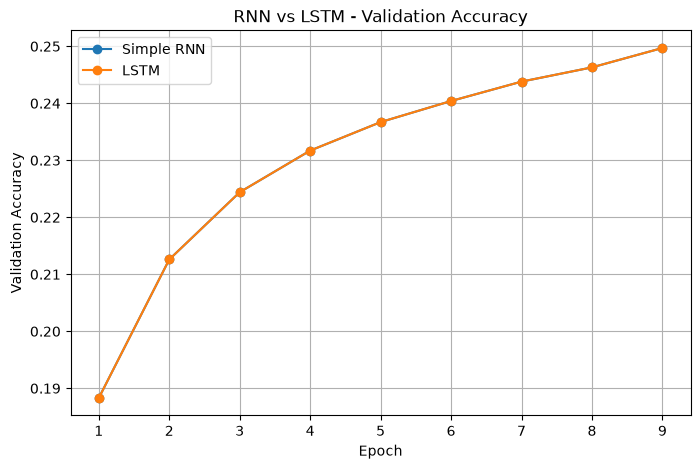

Validation accuracy graph saved.


In [17]:
#Graph 1: Validation accuracy comparison
# Create epoch numbers.
# RNN has 10 epochs and LSTM has 9 epochs,
# so we create them separately.
rnn_epochs = range(1, len(rnn_history) + 1)
lstm_epochs = range(1, len(lstm_history) + 1)


plt.figure(figsize=(8, 5))


# Plot RNN validation accuracy
plt.plot(
    rnn_epochs,
    rnn_history["val_accuracy"],
    marker="o",
    label="Simple RNN"
)


# Plot LSTM validation accuracy
plt.plot(
    lstm_epochs,
    lstm_history["val_accuracy"],
    marker="o",
    label="LSTM"
)


plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "RNN vs LSTM - Validation Accuracy"
)

plt.legend()
plt.grid(True)


# Save graph as PNG
plt.savefig(
    plots_dir / "rnn_vs_lstm_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Validation accuracy graph saved.")